# Lab 5: Regularized Regression

## Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

To clearly observe how regularization behaves, we use a **synthetic dataset** with a controlled feature structure:

| Feature | Role |
|---------|------|
| X1, X2 | Strong predictors — y is a linear function of these |
| X3, X4 | Highly correlated with X1 and X2 (near-redundant) |
| X5, X6 | Pure noise |

In this lab we will:

- Fit **Ridge** and **Lasso** regression models and compare their test performance
- Understand how the regularization parameter **λ** controls the bias–variance trade-off
- Visualize how Ridge and Lasso treat correlated and irrelevant features differently

## Background: The Regularization Penalty

Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and add a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

## Step 1: Load Libraries and Generate Synthetic Data

Run the cells below to import packages and generate the synthetic dataset used throughout the lab.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from ipywidgets import interact, FloatLogSlider
from sklearn.linear_model import LinearRegression


# Seed for reproducibility
np.random.seed(42)
n_samples = 200

# True predictors 
X1 = np.random.normal(0, 1, n_samples)
X2 = np.random.normal(0, 1, n_samples)

# Correlated but redundant features — highly correlated with X1/X2
X3 = X1 + np.random.normal(0, 0.1, n_samples)
X4 = X2 + np.random.normal(0, 0.1, n_samples)

# Pure noise features
X5 = np.random.normal(0, 1, n_samples)
X6 = np.random.normal(0, 1, n_samples)

X = np.column_stack([X1, X2, X3, X4, X5, X6])
y = 3 * X1 + 2 * X2 + np.random.normal(0, 0.5, n_samples)

In [2]:
# Split data into training and testing sets
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Note**: Our synthetic data were drawn from N(0,1), so they are already on the same scale. However, with real environmental data that is often not on the same scale, you would need to scale at this point. 

## Step 2: Fit Ridge Regression

Ridge regression estimates coefficients by minimizing:

$$\text{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2$$

The term $\lambda \sum \beta_j^2$ is the **shrinkage penalty**. It grows when coefficients are large, so the optimizer is pushed toward smaller values. The tuning parameter $\lambda \geq 0$ controls the bias–variance trade-off:

- When $\lambda = 0$, Ridge reduces to ordinary least squares
- As $\lambda \to \infty$, all coefficients shrink toward (but never reach) zero

Ridge keeps *all* predictors in the model. It shrinks their coefficients but never sets any exactly to zero.

Fit a Ridge model using sklearn's default λ and evaluate its performance on the test set.

In [ ]:
# Create and fit Ridge regression model (alpha/lambda = 1)
ridge_model = Ridge().fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Calculate MSE and R^2 for Ridge regression
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MSE: 0.33310286505959696
Ridge Regression R²: 0.9707460703732895


## Step 3: Fit Lasso Regression

The Lasso swaps the $\ell_2$ penalty for an $\ell_1$ penalty:

$$\text{RSS} + \lambda \sum_{j=1}^{p} |\beta_j|$$

This small change has a major consequence: the $\ell_1$ penalty can force coefficient estimates to be **exactly zero**, removing predictors from the model completely. This is what makes Lasso models much easier to interpret than Ridge. 

Fit a Lasso model using sklearn's default λ and compare its performance to Ridge.

In [4]:
# Create and fit Lasso regression model
lasso_model = Lasso().fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# Calculate MSE and R^2 for Lasso regression
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression MSE: 2.120608349468728
Lasso Regression R²: 0.8137628524747943


> **What do you notice?** Compare the Lasso MSE to Ridge. Why might Lasso perform worse at the default λ? What does this suggest about the default regularization strength?

## Step 4: Tune λ and compare MSE Across Regularization Strengths

Create a visualization of λ values ranging from 0.001 to 100 and the MSE that these values yield. Create a line for both ridge and lasso. 

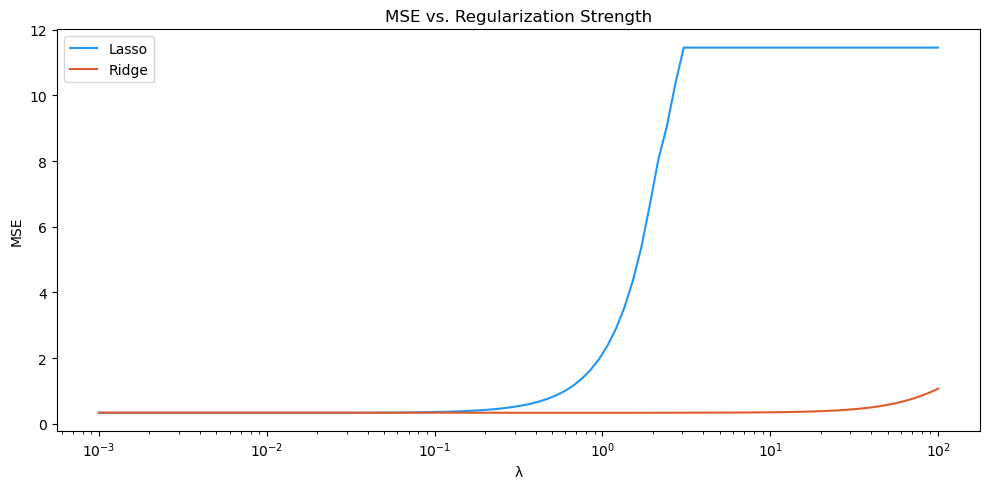

In [ ]:
# Visualize lambdas against MSE for Lasso and Ridge
mse_lasso = []
mse_ridge = []
lambdas = np.logspace(-3, 2, 100)

# 100 values from 0.001 to 100
for lam in lambdas:
    lasso = Lasso(alpha=lam)
    ridge = Ridge(alpha=lam)

    lasso.fit(X_train, y_train)
    ridge.fit(X_train, y_train)

    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='#2196F3')
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

> **What do you notice?** At what λ does each model reach its minimum test MSE? Which model is more sensitive to the choice of λ? What happens to both models as λ becomes very large?

## Step 5: Explore Predictions Interactively

Create an interactive plot that shows how our predictions change as our penalty parameter changes.

In [7]:
# from ipywidgets import FloatLogSlider, Dropdown, HBox, VBox, interactive_output
# from IPython.display import display

# lambda_slider  = FloatLogSlider(value=1.0, base=10, min=-3, max=2, step=0.1, description='λ:')
# model_dropdown = Dropdown(options=['Lasso', 'Ridge'], description='Model:')

# def plot_predictions(lam, model_type):
#     color = '#2196F3' if model_type == 'Lasso' else '#E05B2B'
#     model = Lasso(alpha=lam) if model_type == 'Lasso' else Ridge(alpha=lam)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)

#     mse = mean_squared_error(y_test, y_pred)
#     r2  = r2_score(y_test, y_pred)

#     fig, ax = plt.subplots(figsize=(7, 6))
#     ax.scatter(y_test, y_pred, color=color, alpha=0.6, edgecolors='none', s=50)
#     lims = [min(y_test.min(), y_pred.min()) - 0.5,
#             max(y_test.max(), y_pred.max()) + 0.5]
#     ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
#     ax.set_xlim(lims); ax.set_ylim(lims)
#     ax.set_xlabel('Actual Values', fontsize=12)
#     ax.set_ylabel('Predicted Values', fontsize=12)
#     ax.set_title(
#         f'{model_type}  (λ = {lam:.4f})\nMSE = {mse:.4f}   R² = {r2:.4f}',
#         fontsize=12
#     )
#     ax.legend(fontsize=10)
#     plt.tight_layout()
#     plt.show()
#     plt.close(fig)

# out = interactive_output(plot_predictions, {'lam': lambda_slider, 'model_type': model_dropdown})
# display(VBox([HBox([lambda_slider, model_dropdown]), out]))


> **Try this:** Set λ to a very large value (e.g., 10 or 100) for both models. What happens to the predictions? Now set λ very small (e.g., 0.001). Why do you think a $\lambda$ of 0 fits the best with this data? 

## Step 6: Compare Coefficient Behavior Across λ Values

Create plots to show how Ridge and Lasso coefficients change at four different values of λ (including λ = 0 (OLS)).Take note of how Lasso  zeros out correlated and noise features (variable selection), while Ridge only shrinks them toward zero without ever eliminating them.

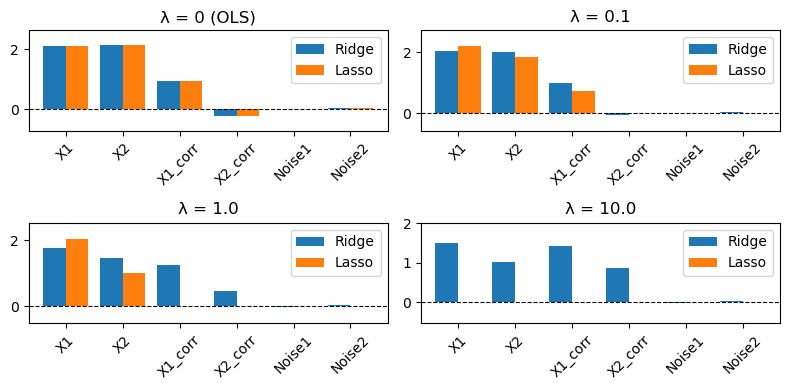

In [9]:
lambdas = [0, 0.1, 1.0, 10.0]
data = []

for lam in lambdas:
    if lam == 0:
        ols = LinearRegression().fit(X_train, y_train)
        data.append(pd.DataFrame({
            'Ridge': ols.coef_,
            'Lasso': ols.coef_
        }, index=['X1', 'X2', 'X1_corr', 'X2_corr', 'Noise1', 'Noise2']))
    else:
        ridge = Ridge(alpha=lam).fit(X_train, y_train)
        lasso = Lasso(alpha=lam).fit(X_train, y_train)
        data.append(pd.DataFrame({
            'Ridge': ridge.coef_,
            'Lasso': lasso.coef_
        }, index=['X1', 'X2', 'X1_corr', 'X2_corr', 'Noise1', 'Noise2']))



fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()
for i, df in enumerate(data):
    df.plot.bar(ax=axes[i], width=0.8)
    title = 'λ = 0 (OLS)' if lambdas[i] == 0 else f'λ = {lambdas[i]}'
    axes[i].set_title(title)
    axes[i].set_xticklabels(df.index, rotation=45)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ymin = min(df.values.min(), 0)
    ymax = max(df.values.max(), 0)
    pad = max((ymax - ymin) * 0.15, 0.5)
    axes[i].set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

> **What do you notice?** Compare the Ridge and Lasso bars at each λ level. Which features does Lasso zero out first? How does Ridge handle the correlated features X3 and X4 compared to Lasso? What are the trade-offs between the two approaches for model interpretability?